# Portland Cement Mortar Comparison

Use graphical summaries to compare modified and unmodified mortar before applying a two-sample t-test.

The modified mortar adds **polymer latex materials** to reduce setup or drying time.

The question is whether this change also reduces **tension bond strength**.

In [1]:
from pathlib import Path

import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import matplotlib.pyplot as plt

# Illustrative Portland cement mortar data.
# Modified values are the common tutorial dataset; unmodified values are chosen
# to match the stated mean 17.04 with similar spread for teaching visualization.
modified = np.array([16.85, 16.40, 17.21, 16.35, 16.52, 17.04, 16.96, 17.15, 16.59, 16.57])
unmodified = np.array([17.28, 16.62, 17.40, 16.81, 17.10, 17.25, 17.04, 16.70, 17.22, 16.98])

mean_mod = modified.mean()
mean_unmod = unmodified.mean()
diff = mean_mod - mean_unmod

print(f"Modified mean: {mean_mod:.2f}")
print(f"Unmodified mean: {mean_unmod:.2f}")
print(f"Difference: {diff:.2f}")

Modified mean: 16.76
Unmodified mean: 17.04
Difference: -0.28


## Visual Comparison

The figure combines three views:

- Dot diagram for the individual observations
- Box plots for spread and median
- Mean comparison with sample standard deviations

/tmp/ipykernel_49208/1703892356.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(
/tmp/ipykernel_49208/1703892356.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0.06, 0.98, 0.96])


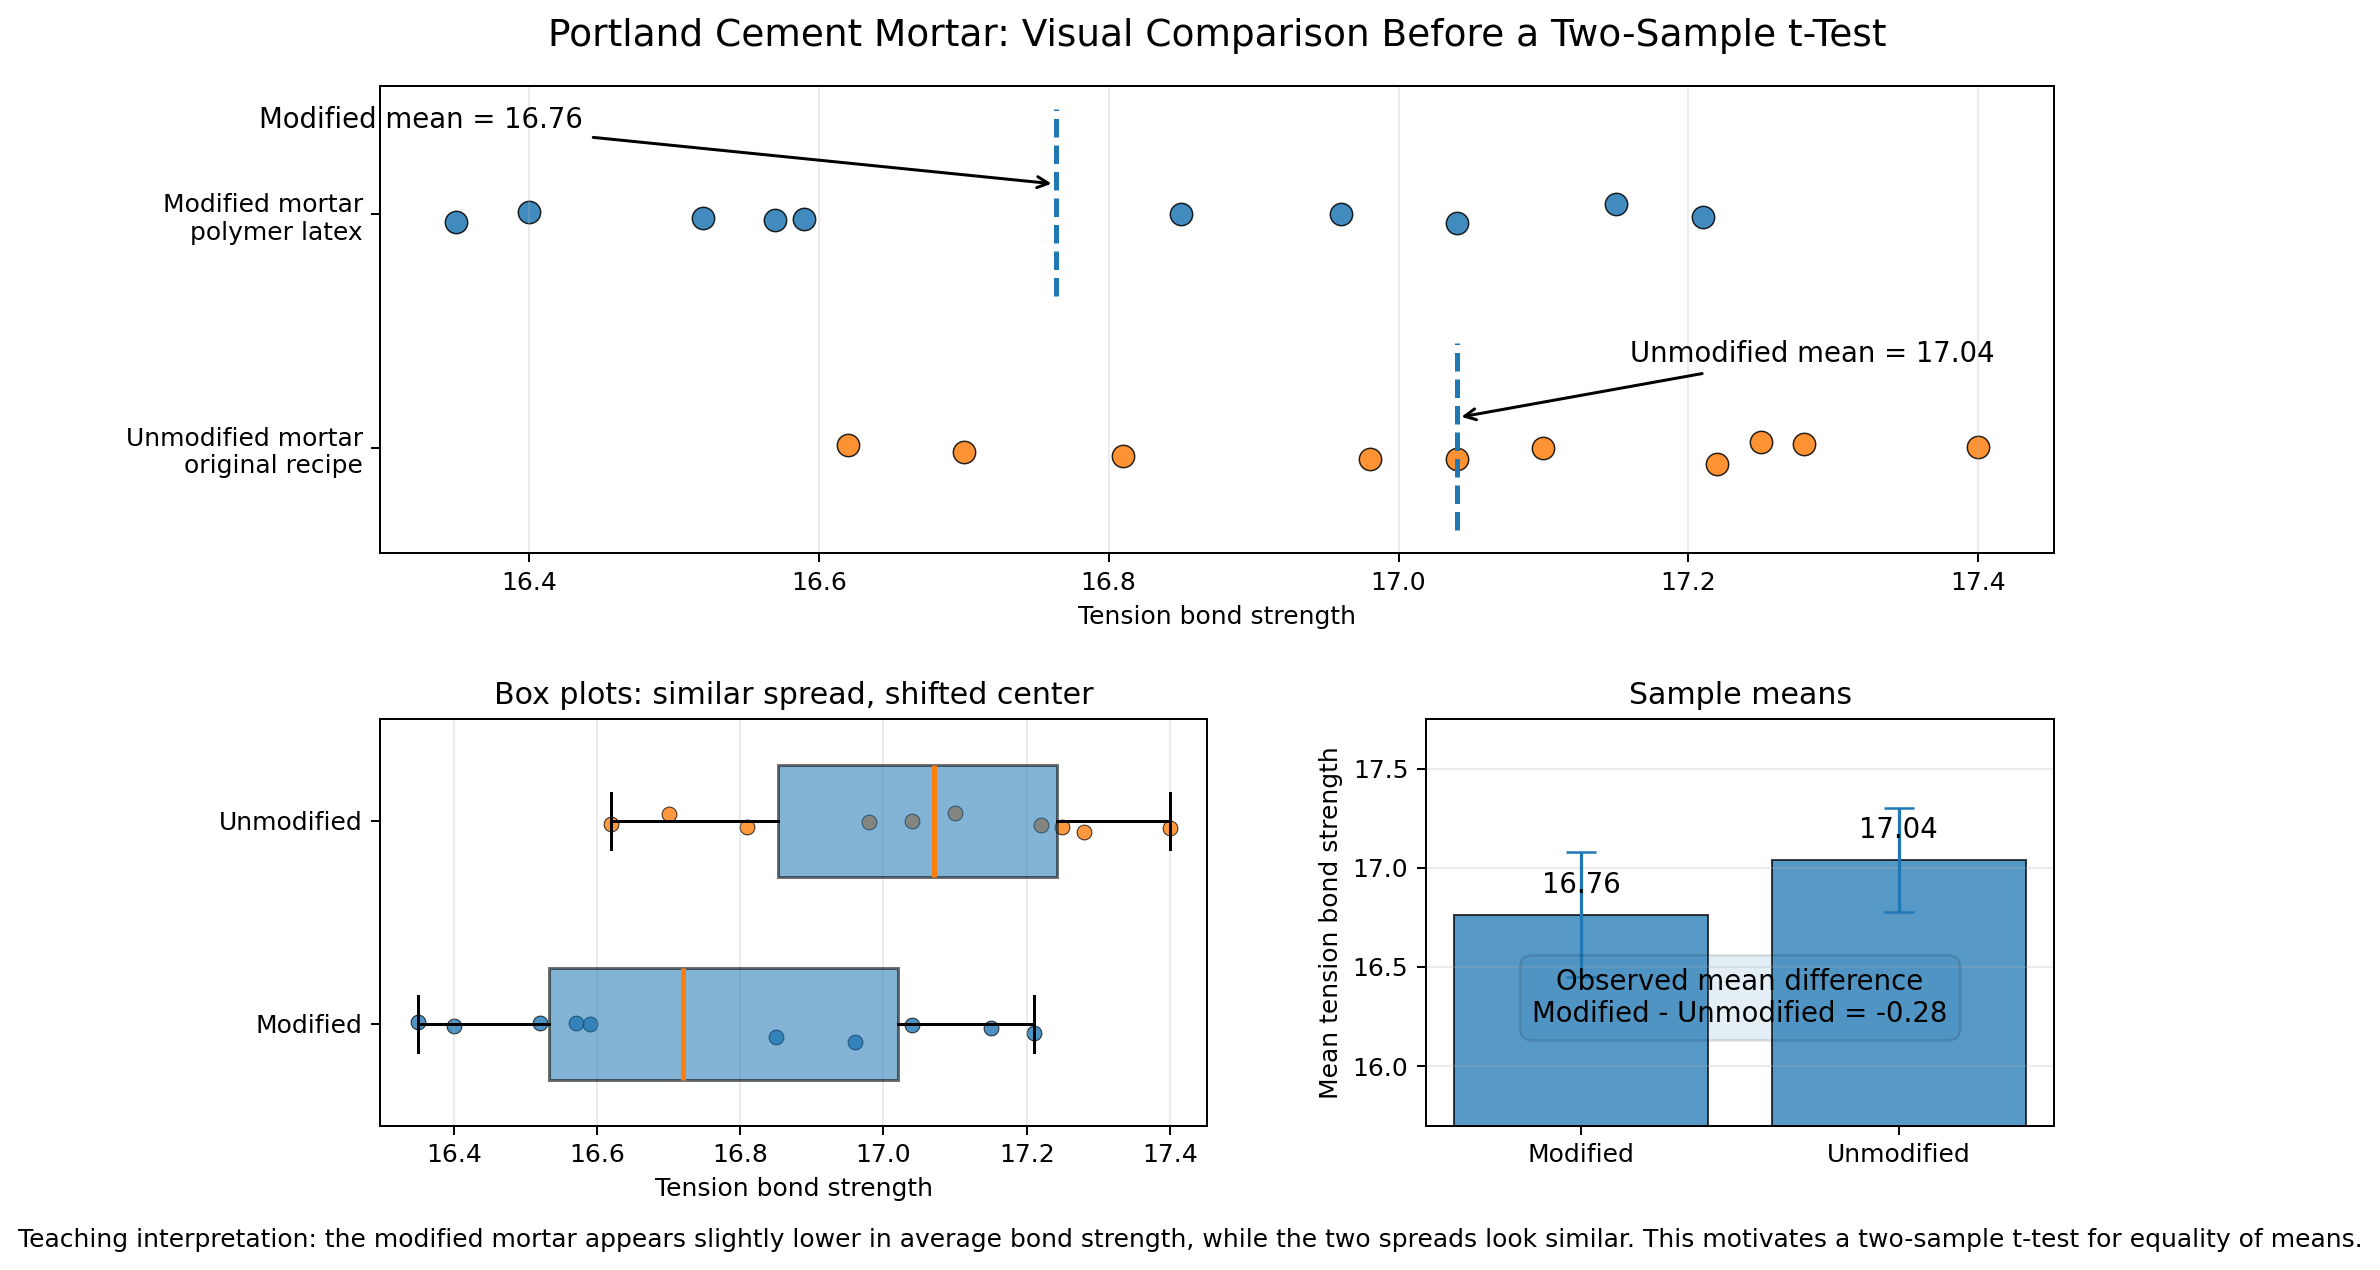

PosixPath('images/portland_cement_ttest_visual.png')

In [2]:
# Deterministic jitter so stacked dots are readable.
rng = np.random.default_rng(7)
jitter_mod = rng.normal(0, 0.035, size=len(modified))
jitter_unmod = rng.normal(0, 0.035, size=len(unmodified))

fig = plt.figure(figsize=(12, 7.5), dpi=180)
gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[1.15, 1],
    width_ratios=[1.25, 0.95],
    hspace=0.38,
    wspace=0.30,
)

# Dot diagram
ax1 = fig.add_subplot(gs[0, :])
y_mod, y_unmod = 1.0, 0.0

ax1.scatter(modified, y_mod + jitter_mod, s=80, alpha=0.85, edgecolor="black", linewidth=0.6)
ax1.scatter(unmodified, y_unmod + jitter_unmod, s=80, alpha=0.85, edgecolor="black", linewidth=0.6)

ax1.axvline(mean_mod, ymin=0.55, ymax=0.95, linestyle="--", linewidth=2)
ax1.axvline(mean_unmod, ymin=0.05, ymax=0.45, linestyle="--", linewidth=2)

ax1.annotate(
    f"Modified mean = {mean_mod:.2f}",
    xy=(mean_mod, y_mod + 0.13),
    xytext=(mean_mod - 0.55, y_mod + 0.37),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=11,
)

ax1.annotate(
    f"Unmodified mean = {mean_unmod:.2f}",
    xy=(mean_unmod, y_unmod + 0.13),
    xytext=(mean_unmod + 0.12, y_unmod + 0.37),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=11,
)

ax1.set_yticks([y_unmod, y_mod])
ax1.set_yticklabels(["Unmodified mortar\noriginal recipe", "Modified mortar\npolymer latex"])
ax1.set_xlabel("Tension bond strength")
ax1.set_title("Portland Cement Mortar: Visual Comparison Before a Two-Sample t-Test", fontsize=15, pad=16)
ax1.grid(axis="x", alpha=0.25)
ax1.set_ylim(-0.45, 1.55)

# Box plot
ax2 = fig.add_subplot(gs[1, 0])
bp = ax2.boxplot(
    [modified, unmodified],
    vert=False,
    labels=["Modified", "Unmodified"],
    patch_artist=True,
    widths=0.55,
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
for patch in bp["boxes"]:
    patch.set_alpha(0.55)

ax2.scatter(modified, np.full_like(modified, 1) + rng.normal(0, 0.035, len(modified)), s=35, alpha=0.8, edgecolor="black", linewidth=0.4)
ax2.scatter(unmodified, np.full_like(unmodified, 2) + rng.normal(0, 0.035, len(unmodified)), s=35, alpha=0.8, edgecolor="black", linewidth=0.4)

ax2.set_xlabel("Tension bond strength")
ax2.set_title("Box plots: similar spread, shifted center")
ax2.grid(axis="x", alpha=0.25)

# Mean difference summary
ax3 = fig.add_subplot(gs[1, 1])
groups = ["Modified", "Unmodified"]
means = [mean_mod, mean_unmod]
stds = [modified.std(ddof=1), unmodified.std(ddof=1)]

ax3.bar(groups, means, alpha=0.75, edgecolor="black", linewidth=0.8)
ax3.errorbar(groups, means, yerr=stds, fmt="none", capsize=6, linewidth=1.3)

for i, m in enumerate(means):
    ax3.text(i, m + 0.08, f"{m:.2f}", ha="center", va="bottom", fontsize=11)

ax3.text(
    0.5,
    min(means) - 0.42,
    f"Observed mean difference\nModified - Unmodified = {diff:.2f}",
    ha="center",
    va="center",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.45", alpha=0.12),
)

ax3.set_ylabel("Mean tension bond strength")
ax3.set_title("Sample means")
ax3.set_ylim(15.7, 17.75)
ax3.grid(axis="y", alpha=0.25)

fig.text(
    0.5,
    0.02,
    "Teaching interpretation: the modified mortar appears slightly lower in average bond strength, while the two spreads look similar. "
    "This motivates a two-sample t-test for equality of means.",
    ha="center",
    fontsize=10,
)

plt.tight_layout(rect=[0.03, 0.06, 0.98, 0.96])

image_dir = Path("doe/images") if Path("doe").exists() else Path("images")
image_dir.mkdir(parents=True, exist_ok=True)
out = image_dir / "portland_cement_ttest_visual.png"
plt.savefig(out, bbox_inches="tight")
plt.show()

out

## Core Code to Remember

```python
modified.mean()
unmodified.mean()
modified.std(ddof=1)
unmodified.std(ddof=1)

ax.scatter(modified, y_mod + jitter_mod)
ax.boxplot([modified, unmodified], vert=False)
ax.bar(["Modified", "Unmodified"], [mean_mod, mean_unmod])
ax.errorbar(groups, means, yerr=stds, fmt="none")
```